# Section 3: AI Automation — NLP Chatbot for Customer Queries & Actions

**Pipeline Overview**

| Stage | Technology | Role |
|---|---|---|
| NLP Backend | spaCy `en_core_web_sm` + PhraseMatcher | Entity extraction (service names, dates) |
| Intent Classifier | `CountVectorizer` + `SGDClassifier` (SVM) | Query understanding (8 intents) |
| Dialogue Manager | Finite-State Conversation Engine | Multi-turn context tracking |
| Actions | Simulated booking / reschedule / cancel ops | Agentic response execution |
| Persistence | `joblib` → `chatbot_model.pkl` | Save/load full artifact |

**Supported Intents:** `greet` · `farewell` · `make_booking` · `cancel_booking` · `check_price` · `change_booking` · `get_recommendation` · `confirm_yes` · `confirm_no`

No external APIs required — fully local pipeline.

## Step 1 — Imports & Directory Setup

In [25]:
import os
import re
import random
import joblib
import warnings
import numpy as np
import pandas as pd
from enum import Enum, auto
from datetime import datetime

import spacy
from spacy.matcher import PhraseMatcher

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from dateutil import parser as date_parser

warnings.filterwarnings("ignore")
sns.set_theme(style="ticks", palette="Set2")

OUT_ANALYSIS = os.path.join("..", "images")
OUT_MODELS   = os.path.join("..", "models")
os.makedirs(OUT_ANALYSIS, exist_ok=True)
os.makedirs(OUT_MODELS,   exist_ok=True)

# Load spaCy
nlp_engine = spacy.load("en_core_web_sm")
print("spaCy pipeline loaded:", nlp_engine.meta["name"])

spaCy pipeline loaded: core_web_sm


## Step 2 — Wellness Service Catalog

In [26]:
# (name, price_tier, category)
WELLNESS_CATALOG = [
    ("Swedish Massage",               "mid",     "massage"),
    ("Deep Tissue Massage",           "mid",     "massage"),
    ("Hot Stone Massage",             "premium", "massage"),
    ("Aromatherapy Massage",          "premium", "massage"),
    ("Sports Massage",                "mid",     "massage"),
    ("Prenatal Massage",              "mid",     "massage"),
    ("Couples Massage",               "premium", "massage"),
    ("Classic Facial",                "budget",  "facial"),
    ("Anti-Aging Facial",             "premium", "facial"),
    ("Hydrating Facial",              "mid",     "facial"),
    ("Acne Treatment Facial",         "budget",  "facial"),
    ("Reflexology",                   "budget",  "body"),
    ("Body Scrub & Wrap",             "mid",     "body"),
    ("Lymphatic Drainage",            "mid",     "body"),
    ("Wellness Package",              "premium", "package"),
    ("Corporate Wellness Session",    "premium", "package"),
    ("Meditation & Breathwork",       "budget",  "alternative"),
    ("Infrared Sauna Session",        "mid",     "alternative"),
    ("Cryotherapy",                   "premium", "alternative"),
    ("Cupping Therapy",               "budget",  "alternative"),
    ("Reiki Healing",                 "mid",     "alternative"),
    ("Sound Bath Therapy",            "budget",  "alternative"),
    ("Ayurvedic Treatment",           "premium", "alternative"),
    ("Float Tank Session",            "mid",     "alternative"),
    ("Stretching & Mobility Session", "budget",  "body"),
]

SVC_NAMES    = [n for n, _, _ in WELLNESS_CATALOG]
SVC_TIER     = {n: t for n, t, _ in WELLNESS_CATALOG}
SVC_CATEGORY = {n: c for n, _, c in WELLNESS_CATALOG}

BY_TIER = {"budget": [], "mid": [], "premium": []}
BY_CAT  = {}
for name, tier, cat in WELLNESS_CATALOG:
    BY_TIER[tier].append(name)
    BY_CAT.setdefault(cat, []).append(name)

PRICE_GUIDE = {
    "budget":  "$50 – $95",
    "mid":     "$110 – $190",
    "premium": "$220 – $380",
}

print(f"Catalog size  : {len(SVC_NAMES)} services")
print(f"Price tiers   : {list(BY_TIER.keys())}")
print(f"Categories    : {list(BY_CAT.keys())}")

Catalog size  : 25 services
Price tiers   : ['budget', 'mid', 'premium']
Categories    : ['massage', 'facial', 'body', 'package', 'alternative']


## Step 3 — Intent Training Data

We define **8 intent classes** with ~40+ unique training phrases each.  
Phrasing is deliberately varied — short, long, formal, casual — to improve generalisation.

In [27]:
INTENT_CORPUS = {
    # ── GREET ────────────────────────────────────────────────────────────────
    "greet": [
        "hi", "hello", "hey", "good morning", "good afternoon", "good evening",
        "howdy", "what's up", "yo", "hiya", "hey there", "hi there", "greetings",
        "hello there", "sup", "hey, anyone around?", "hi, I need some help",
        "hello, can you assist me", "hey, got a question", "hi, is this the right place",
        "good morning, quick question", "hello, I'm a new customer",
        "hi, I'm looking for information", "hey, I'd like some assistance please",
        "good evening, can you help me out", "hello, I just joined",
        "hi, I'd like to know more about your services",
        "hey there, do you have a moment", "good afternoon, I have an inquiry",
        "hi, can someone help me", "hey, quick one for you",
        "hello, I'm reaching out for help", "hi, thanks for being here",
        "good morning, I need guidance", "hey, I'm a bit lost",
        "hi there, hoping you can help", "hello, I'm not sure where to start",
        "good day", "hi, just checking in", "hello, nice to meet you",
        "hey, I'd appreciate some help",
    ],

    # ── FAREWELL ─────────────────────────────────────────────────────────────
    "farewell": [
        "bye", "goodbye", "see you", "thanks, bye", "thank you so much",
        "that's all I needed", "cheers", "take care", "have a great day",
        "I'm all set, thanks", "you've been very helpful", "thanks a lot",
        "I'm done for now", "that's everything, thank you", "see ya",
        "all good, bye", "appreciate your help", "thanks for your assistance",
        "great, that helped", "perfect, thank you", "I got what I needed",
        "thank you very much", "much appreciated", "that's it from me",
        "we're done here, thanks", "thanks a bunch", "lovely, thanks",
        "brilliant, that's all", "you've been helpful, bye", "laters",
        "ok thanks", "ok, I'm sorted", "no more questions, thanks",
        "that answers everything, cheers", "thanks for the help",
        "I appreciate it, goodbye", "ok bye", "done, thank you",
        "have a good one", "all sorted, cheers",
    ],

    # ── MAKE_BOOKING ─────────────────────────────────────────────────────────
    "make_booking": [
        "I want to book a massage", "book me a session", "I'd like to make a booking",
        "can I schedule an appointment", "I need to book a service",
        "set up an appointment for me", "reserve a slot", "I want to schedule",
        "I'd like to book a facial", "can you book me in", "I want an appointment",
        "book a deep tissue massage for me", "I want to reserve a treatment",
        "please make a booking", "I'd like to arrange an appointment",
        "can I get a booking for a massage", "I need an appointment this week",
        "I want to book a hot stone massage", "make me an appointment please",
        "can I book a session today", "I'd like to get a slot",
        "I want to come in for a treatment", "set me up with a booking",
        "I want to book a wellness session", "how do I make a booking",
        "can you help me schedule a session", "I'd like to book a couples massage",
        "book me in for a body treatment", "reserve a relaxation session for me",
        "I want to get a cryotherapy session", "schedule me for a facial please",
        "I'd like an appointment for next week", "can I book a float tank session",
        "help me book a sauna session", "I need to set up a booking for a massage",
        "I'm looking to book a service", "make an appointment for Swedish Massage",
        "can you schedule a session for me", "I'd like to book something",
        "I want to arrange a facial appointment", "help me book a slot",
        "I need to schedule a treatment", "book me for a relaxation session",
        "I'd like to make an appointment please",
    ],

    # ── CANCEL_BOOKING ───────────────────────────────────────────────────────
    "cancel_booking": [
        "cancel my booking", "I need to cancel my appointment", "please cancel my session",
        "I want to cancel", "can I cancel my reservation", "remove my appointment",
        "I'd like to cancel my treatment", "cancel my massage appointment",
        "can you cancel my booking for me", "I have to cancel my session",
        "I want to delete my booking", "please remove my reservation",
        "cancel my upcoming appointment", "I need to call off my session",
        "can I get a cancellation", "I'd like to cancel my slot",
        "please terminate my booking", "I want out of my appointment",
        "undo my booking", "I have to cancel unfortunately",
        "cancel everything", "I don't want my booking anymore",
        "please call off my treatment", "I'd like my booking cancelled",
        "can you remove my session", "I'm cancelling my appointment",
        "I need to back out of my appointment", "take me off the schedule",
        "remove me from the booking", "I want to withdraw my booking",
        "I need a refund and cancellation", "can I cancel and get a refund",
        "please cancel the session I have", "I'd like my reservation cancelled",
        "I want to cancel my hot stone massage", "cancel my facial booking",
        "I need to cancel my upcoming session", "can I call off my treatment",
        "please help me cancel", "how do I cancel my booking",
        "I want to stop my appointment",
    ],

    # ── CHECK_PRICE ──────────────────────────────────────────────────────────
    "check_price": [
        "how much does it cost", "what are your prices", "how much is a massage",
        "tell me the price", "what's the rate for a facial", "pricing information please",
        "how much for a hot stone massage", "what do you charge", "cost of treatments",
        "I want to know the price", "what's the fee", "is it expensive",
        "how much does Swedish Massage cost", "give me the pricing details",
        "what are your treatment rates", "I'd like to know the cost",
        "how much for a session", "what does a massage go for",
        "can you quote me a price", "I need pricing info",
        "how much is a body scrub", "what's your most affordable service",
        "do you have pricing info online", "I'm trying to understand the costs",
        "tell me what each service costs", "what's your cheapest option",
        "how much is a premium service", "what do your luxury treatments cost",
        "I want a quote for a deep tissue massage", "how much does cryotherapy cost",
        "what's the pricing for wellness packages", "give me a price breakdown",
        "I'd like a price list please", "how much should I budget for a massage",
        "cost of a float tank session", "what's the charge for reflexology",
        "I'm curious about your rates", "what's a typical price for your services",
        "what does a facial treatment cost", "pricing for sauna session",
    ],

    # ── CHANGE_BOOKING ───────────────────────────────────────────────────────
    "change_booking": [
        "Can I reschedule my booking", "I need to change my appointment time",
        "move my booking to a different date", "I want to reschedule my session",
        "can you shift my appointment", "I need to change the time of my booking",
        "reschedule my massage", "I'd like to change my appointment",
        "can I pick a different date for my session", "I need to push my booking back",
        "can I move my booking forward", "I want to change the date of my appointment",
        "please reschedule me", "I'd like to book a different time slot",
        "I need to reschedule my facial", "change my booking time please",
        "can I get a different appointment slot", "I want a different time for my session",
        "reschedule my treatment", "can I postpone my booking",
        "I have to reschedule my appointment", "move my session to next week",
        "I'd like to change my booking date", "reschedule my hot stone massage",
        "can you update my appointment time", "shift my booking please",
        "I need to move my appointment", "change the schedule for my session",
        "I want to change when I come in", "can I rebook for a later time",
        "I want to reschedule my wellness session", "put my appointment at a new time",
        "I can't make it, can we reschedule", "I'd like to reschedule please",
        "change my appointment to tomorrow", "move my booking to Monday",
        "I need to reschedule urgently", "can I change my session date",
        "please update my booking to a new date", "I want my appointment at a different time",
    ],

    # ── GET_RECOMMENDATION ───────────────────────────────────────────────────
    "get_recommendation": [
        "what do you recommend", "suggest a service for me", "what's your best service",
        "which treatment should I try", "I need a recommendation",
        "what service would you suggest", "I'm not sure what to book",
        "what's popular", "help me choose a service", "recommend something for stress relief",
        "what's good for muscle pain", "what should I try first",
        "any suggestions for relaxation", "I want something calming",
        "what's your top pick", "what do most people book",
        "I'm new here, what do you suggest", "can you guide me on what to choose",
        "what treatment is best for me", "I'd like a personalised recommendation",
        "what's a good starter service", "what works well for back pain",
        "recommend a facial for dry skin", "what's good for anxiety",
        "I want something luxurious", "what's affordable and good",
        "can you suggest a budget-friendly option", "what's your premium service",
        "I want to try something new, what do you suggest",
        "what would you pick if you were me", "suggest something rejuvenating",
        "I'm looking for something unique", "what's trending right now",
        "recommend a couples treatment", "what's ideal for a special occasion",
        "suggest something for a first-timer", "what should a beginner try",
        "I want a recommendation for deep relaxation", "guide me to the best service",
        "I'm open to suggestions", "what are your hidden gems",
    ],

    # ── CONFIRM_YES ──────────────────────────────────────────────────────────
    "confirm_yes": [
        "yes", "yeah", "yep", "sure", "absolutely", "of course", "please do",
        "yes please", "go ahead", "that's right", "correct", "affirmative",
        "you bet", "definitely", "indeed", "ok yes", "that works",
        "sounds good", "I'd like that", "please", "yes, that would be great",
        "yes, go for it", "yup", "alright", "sure thing", "yes, assist me",
        "yes please, I'd appreciate that", "please help", "I agree",
        "that's fine", "okay", "ok", "I'm happy with that", "I confirm",
        "confirmed", "let's do it", "I'm in", "proceed", "go on",
        "yep, let's do it", "please assist",
    ],

    # ── CONFIRM_NO ───────────────────────────────────────────────────────────
    "confirm_no": [
        "no", "nope", "no thanks", "I'm good", "not really", "don't worry about it",
        "I'll manage", "that's ok, no", "don't bother", "actually, no",
        "I don't want that", "negative", "not interested", "no need",
        "I'll pass", "maybe later", "not right now", "nah", "I'm fine",
        "no, that's alright", "I changed my mind", "forget it",
        "no thank you", "no, I'll do it myself", "I don't think so",
        "actually never mind", "cancel that", "not needed", "I'm ok",
        "no, I just wanted to know", "no worries, I'll sort it myself",
        "no, I was just asking", "I'll handle it", "that won't be necessary",
        "no, I'm set", "no, I'm fine thanks", "I'm sorted, no thanks",
        "it's ok, no", "don't need help", "no, not yet",
    ],
}

for intent, phrases in INTENT_CORPUS.items():
    print(f"  {intent:<22} → {len(phrases):>3} examples")
print(f"  {'TOTAL':<22} → {sum(len(v) for v in INTENT_CORPUS.values()):>3} examples")

  greet                  →  41 examples
  farewell               →  40 examples
  make_booking           →  44 examples
  cancel_booking         →  41 examples
  check_price            →  40 examples
  change_booking         →  40 examples
  get_recommendation     →  41 examples
  confirm_yes            →  41 examples
  confirm_no             →  40 examples
  TOTAL                  → 368 examples


## Step 4 — Train Intent Classifier (CountVectorizer + SGDClassifier)

We use `sklearn.pipeline.Pipeline` to chain:
1. **CountVectorizer** with bigrams — captures word sequences like "reschedule my"
2. **SGDClassifier** with hinge loss — equivalent to a linear SVM, fast and effective for text

In [28]:
# Flatten corpus into (text, label) pairs
all_texts, all_labels = [], []
for intent_label, phrase_list in INTENT_CORPUS.items():
    all_texts.extend(phrase_list)
    all_labels.extend([intent_label] * len(phrase_list))

X_train, X_test, y_train, y_test = train_test_split(
    all_texts, all_labels, test_size=0.18, random_state=99, stratify=all_labels
)

# Build sklearn Pipeline
intent_pipeline = Pipeline([
    ("vectoriser", CountVectorizer(
        ngram_range=(1, 2),
        min_df=1,
        strip_accents="unicode",
        analyzer="word",
    )),
    ("classifier", SGDClassifier(
        loss="hinge",          # Linear SVM
        alpha=0.0001,
        max_iter=200,
        tol=1e-4,
        random_state=42,
        class_weight="balanced",
    )),
])

intent_pipeline.fit(X_train, y_train)
y_pred = intent_pipeline.predict(X_test)

hold_out_acc = accuracy_score(y_test, y_pred)
cv_scores    = cross_val_score(intent_pipeline, all_texts, all_labels, cv=5, scoring="accuracy")

print(f"Hold-out accuracy : {hold_out_acc:.4f}")
print(f"5-Fold CV accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print()

intent_labels_sorted = sorted(INTENT_CORPUS.keys())
report_str  = classification_report(y_test, y_pred, labels=intent_labels_sorted)
report_dict = classification_report(y_test, y_pred, labels=intent_labels_sorted, output_dict=True)
print(report_str)

Hold-out accuracy : 0.7612
5-Fold CV accuracy: 0.7827 ± 0.0612

                    precision    recall  f1-score   support

    cancel_booking       0.89      1.00      0.94         8
    change_booking       0.75      0.86      0.80         7
       check_price       0.60      0.43      0.50         7
        confirm_no       0.71      0.71      0.71         7
       confirm_yes       0.60      0.75      0.67         8
          farewell       0.75      0.86      0.80         7
get_recommendation       1.00      0.62      0.77         8
             greet       1.00      0.57      0.73         7
      make_booking       0.73      1.00      0.84         8

          accuracy                           0.76        67
         macro avg       0.78      0.76      0.75        67
      weighted avg       0.78      0.76      0.75        67



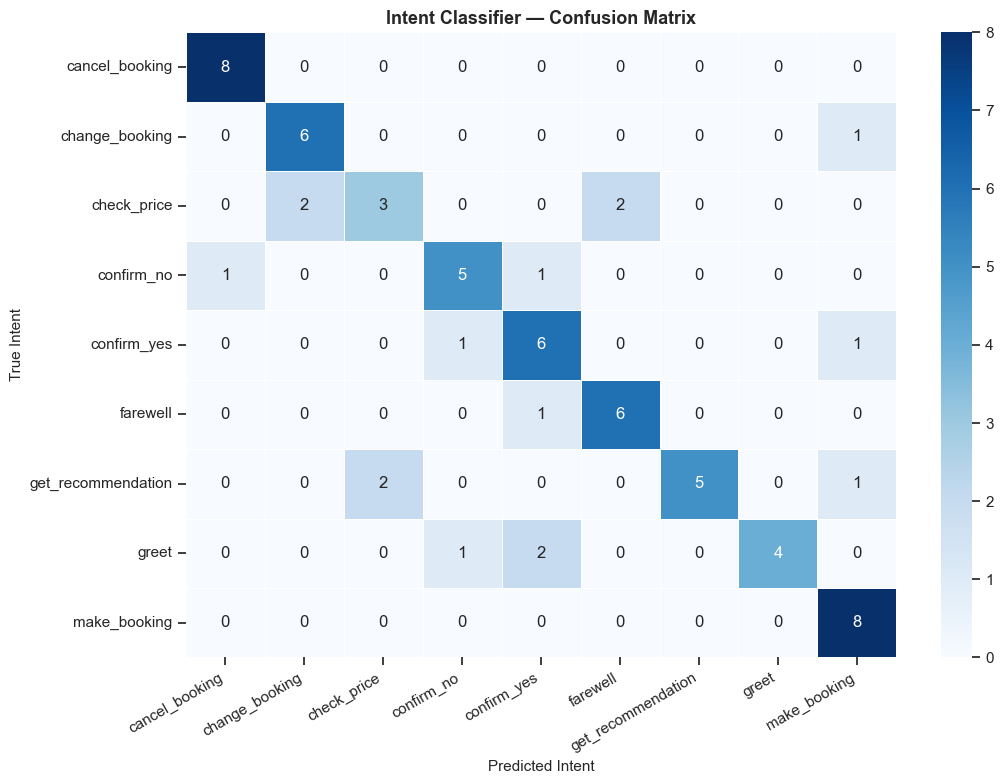

In [29]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred, labels=intent_labels_sorted)

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=intent_labels_sorted,
    yticklabels=intent_labels_sorted,
    linewidths=0.4, ax=ax,
)
ax.set_xlabel("Predicted Intent", fontsize=11)
ax.set_ylabel("True Intent",      fontsize=11)
ax.set_title("Intent Classifier — Confusion Matrix", fontsize=13, fontweight="bold")
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(OUT_ANALYSIS, "chatbot_confusion_matrix.png"), dpi=150, bbox_inches="tight")
plt.show()

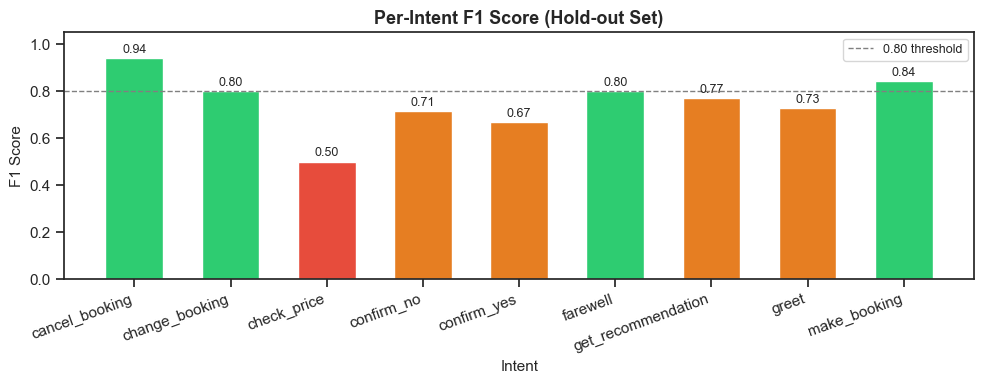

In [30]:
# ── Per-Intent F1 Score Bar Chart ─────────────────────────────────────────────
f1_vals   = [report_dict[lbl]["f1-score"] for lbl in intent_labels_sorted]
bar_colors = ["#2ecc71" if f >= 0.80 else "#e67e22" if f >= 0.60 else "#e74c3c" for f in f1_vals]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(intent_labels_sorted, f1_vals, color=bar_colors, edgecolor="white", width=0.6)
ax.axhline(0.80, color="grey", linestyle="--", linewidth=1, label="0.80 threshold")
ax.set_ylim(0, 1.05)
ax.set_xlabel("Intent", fontsize=11)
ax.set_ylabel("F1 Score",  fontsize=11)
ax.set_title("Per-Intent F1 Score (Hold-out Set)", fontsize=13, fontweight="bold")
for bar, val in zip(bars, f1_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.2f}", ha="center", va="bottom", fontsize=9)
ax.legend(fontsize=9)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(OUT_ANALYSIS, "chatbot_f1_per_intent.png"), dpi=150, bbox_inches="tight")
plt.show()

## Step 5 — NLP Entity Extractor (spaCy)

Two extractors work together:
1. **PhraseMatcher** — finds known service names in raw text
2. **Date/Time parser** — uses `dateutil` to parse any date/time expression

In [31]:
# ── Build PhraseMatcher for service names ─────────────────────────────────────
phrase_matcher = PhraseMatcher(nlp_engine.vocab, attr="LOWER")
svc_patterns   = [nlp_engine.make_doc(name.lower()) for name in SVC_NAMES]
phrase_matcher.add("SERVICE", svc_patterns)


def extract_service(raw_text: str):
    """Return first matched service name from text, or None."""
    doc     = nlp_engine(raw_text.lower())
    matches = phrase_matcher(doc)
    if matches:
        _, start, end = matches[0]
        matched_lower = doc[start:end].text
        # Map back to properly-cased name
        for svc in SVC_NAMES:
            if svc.lower() == matched_lower:
                return svc
    return None


def extract_datetime(raw_text: str):
    """
    Return a datetime object parsed from text, or None.
    Tries dateutil first; falls back to regex for common short forms.
    """
    # Regex for patterns like "30 Mar 2025 10 am"
    patterns = [
        r"\d{1,2}\s+[A-Za-z]+\s+\d{4}\s+\d{1,2}(?::\d{2})?\s*[aApP][mM]",
        r"[A-Za-z]+\s+\d{1,2},?\s+\d{4}\s+(?:at\s+)?\d{1,2}(?::\d{2})?\s*[aApP][mM]",
        r"\d{1,2}/\d{1,2}/\d{2,4}\s+\d{1,2}(?::\d{2})?\s*[aApP][mM]",
    ]
    for pat in patterns:
        m = re.search(pat, raw_text, re.IGNORECASE)
        if m:
            try:
                return date_parser.parse(m.group(), dayfirst=True)
            except Exception:
                pass
    # Fallback: full string parse
    try:
        return date_parser.parse(raw_text, dayfirst=True, fuzzy=True)
    except Exception:
        return None


# ── Quick sanity checks ───────────────────────────────────────────────────────
test_entities = [
    "I'd like a Swedish Massage please",
    "30 Mar 2025 10 am",
    "April 15, 2025 at 2:00 PM",
    "book me a Hot Stone Massage on March 20",
]
print("Entity extraction tests:")
for txt in test_entities:
    svc = extract_service(txt)
    dt  = extract_datetime(txt)
    print(f"  Input : {txt!r}")
    print(f"  → service={svc}  |  datetime={dt}")
    print()

Entity extraction tests:
  Input : "I'd like a Swedish Massage please"
  → service=Swedish Massage  |  datetime=None

  Input : '30 Mar 2025 10 am'
  → service=None  |  datetime=2025-03-30 10:00:00

  Input : 'April 15, 2025 at 2:00 PM'
  → service=None  |  datetime=2025-04-15 14:00:00

  Input : 'book me a Hot Stone Massage on March 20'
  → service=Hot Stone Massage  |  datetime=2026-03-20 00:00:00



## Step 6 — Dialogue State Machine

The `ConversationState` enum defines every possible state in the dialogue.  
The `ChatSession` class holds per-conversation context and drives state transitions.

In [32]:
class ConversationState(Enum):
    IDLE               = auto()   # No active flow
    AWAIT_RESCHEDULE   = auto()   # Asked "reschedule?" → waiting for yes/no
    AWAIT_NEW_DATETIME = auto()   # Confirmed reschedule → waiting for new date
    AWAIT_BOOK_SERVICE = auto()   # Booking intent → waiting for service name
    AWAIT_BOOK_DATETIME= auto()   # Got service → waiting for date/time
    AWAIT_CANCEL_REF   = auto()   # Cancel intent → waiting for booking reference
    AWAIT_PRICE_SVC    = auto()   # Price intent, no service → waiting for service
    AWAIT_REC_PREF     = auto()   # Recommendation intent → waiting for preference


class ChatSession:
    """Stateful single-user conversation session."""

    def __init__(self):
        self.state          = ConversationState.IDLE
        self.booked_service = None   # service name currently being processed
        self.booked_at      = None   # datetime for booking/reschedule
        self.turn_count     = 0

    def _classify(self, text: str) -> str:
        return intent_pipeline.predict([text])[0]

    def _format_dt(self, dt: datetime) -> str:
        return dt.strftime("%d %b %Y at %I:%M %p")

    # ── Recommendation helper ─────────────────────────────────────────────────
    def _pick_recommendation(self, pref_text: str):
        lower = pref_text.lower()
        # Keyword-based preference routing
        if any(kw in lower for kw in ["stress", "relax", "calm", "peaceful", "unwind", "sooth"]):
            pool = BY_CAT["massage"] + ["Meditation & Breathwork", "Sound Bath Therapy", "Float Tank Session"]
        elif any(kw in lower for kw in ["pain", "muscle", "sport", "athletic", "tension", "stiff"]):
            pool = ["Deep Tissue Massage", "Sports Massage", "Stretching & Mobility Session", "Cupping Therapy"]
        elif any(kw in lower for kw in ["skin", "face", "facial", "glow", "anti-aging", "acne"]):
            pool = BY_CAT["facial"]
        elif any(kw in lower for kw in ["budget", "cheap", "affordable", "value"]):
            pool = BY_TIER["budget"]
        elif any(kw in lower for kw in ["luxury", "premium", "indulge", "special"]):
            pool = BY_TIER["premium"]
        elif any(kw in lower for kw in ["couple", "partner", "date", "together"]):
            pool = ["Couples Massage", "Wellness Package"]
        else:
            pool = BY_CAT["massage"]  # safe default
        pick = random.choice(pool)
        tier = SVC_TIER[pick]
        return pick, PRICE_GUIDE[tier]

    # ── Main turn handler ─────────────────────────────────────────────────────
    def respond(self, user_input: str) -> str:
        self.turn_count += 1
        text    = user_input.strip()
        intent  = self._classify(text)
        svc_ent = extract_service(text)
        dt_ent  = extract_datetime(text)

        # ── STATE: AWAIT_RESCHEDULE ─────────────────────────────────────────
        if self.state == ConversationState.AWAIT_RESCHEDULE:
            if intent == "confirm_yes":
                self.state = ConversationState.AWAIT_NEW_DATETIME
                return "Please provide the new date that you would like to reschedule your booking at."
            else:
                self.state = ConversationState.IDLE
                return ("No problem! Your booking remains unchanged. "
                        "Let me know if there's anything else I can help you with.")

        # ── STATE: AWAIT_NEW_DATETIME ───────────────────────────────────────
        if self.state == ConversationState.AWAIT_NEW_DATETIME:
            if dt_ent:
                self.booked_at = dt_ent
                self.state     = ConversationState.IDLE
                return ("Sent reschedule information to pro, "
                        f"you will get notified once it's confirmed — "
                        f"new date: {self._format_dt(dt_ent)}.")
            return ("I couldn't quite read that date. "
                    "Could you try again? For example: \"30 Mar 2025 10 am\"")

        # ── STATE: AWAIT_BOOK_SERVICE ───────────────────────────────────────
        if self.state == ConversationState.AWAIT_BOOK_SERVICE:
            if svc_ent:
                self.booked_service = svc_ent
                self.state = ConversationState.AWAIT_BOOK_DATETIME
                return (f"Great choice! {svc_ent} selected. "
                        "What date and time would you like to book it?")
            return ("I didn't catch a service name. "
                    f"We offer: {', '.join(SVC_NAMES[:5])}, and more. Which would you like?")

        # ── STATE: AWAIT_BOOK_DATETIME ──────────────────────────────────────
        if self.state == ConversationState.AWAIT_BOOK_DATETIME:
            if dt_ent:
                self.booked_at = dt_ent
                svc = self.booked_service
                self.state = ConversationState.IDLE
                return (f"Your {svc} has been booked for {self._format_dt(dt_ent)}. "
                        "You'll receive a confirmation shortly. Is there anything else?")
            return ("Please share the date and time, e.g. \"April 15, 2025 at 2 PM\". "
                    "When would you like to come in?")

        # ── STATE: AWAIT_CANCEL_REF ─────────────────────────────────────────
        if self.state == ConversationState.AWAIT_CANCEL_REF:
            ref_match = re.search(r"\b(BK[\-\s]?\d{4,}[\-\d]*|\d{6,})\b", text, re.IGNORECASE)
            if ref_match:
                ref_no = ref_match.group().upper()
                self.state = ConversationState.IDLE
                return (f"Booking {ref_no} has been successfully cancelled. "
                        "A confirmation will be sent to your registered email. "
                        "Is there anything else I can help you with?")
            return ("I need your booking reference number to proceed. "
                    "It looks like BK-YYYYMMDD-XXX and can be found in your confirmation email.")

        # ── STATE: AWAIT_PRICE_SVC ──────────────────────────────────────────
        if self.state == ConversationState.AWAIT_PRICE_SVC:
            if svc_ent:
                tier  = SVC_TIER[svc_ent]
                price = PRICE_GUIDE[tier]
                self.state = ConversationState.IDLE
                return (f"{svc_ent} is a {tier}-tier service, "
                        f"priced at {price}. "
                        "Would you like to book it?")
            return ("Which service are you asking about? "
                    "For example: 'Swedish Massage', 'Hot Stone Massage', 'Classic Facial'.")

        # ── STATE: AWAIT_REC_PREF ───────────────────────────────────────────
        if self.state == ConversationState.AWAIT_REC_PREF:
            suggested, price = self._pick_recommendation(text)
            self.state = ConversationState.IDLE
            return (f"Based on your preference, I'd recommend **{suggested}** "
                    f"({price}). "
                    "Would you like to book it?")

        # ── IDLE: Route by intent ───────────────────────────────────────────
        if intent == "greet":
            return ("Hello! Welcome to Blyss Wellness 🌿 "
                    "I can help you book, cancel, reschedule, get pricing, "
                    "or recommend a service. What would you like to do?")

        if intent == "farewell":
            self.state = ConversationState.IDLE
            return "You're welcome! Have a wonderful day. We look forward to seeing you soon. 🙏"

        if intent == "change_booking":
            # Check if datetime is already in the query
            if dt_ent:
                self.booked_at = dt_ent
                self.state     = ConversationState.IDLE
                return (f"Sent reschedule information to pro, "
                        f"you will get notified once it's confirmed — "
                        f"new date: {self._format_dt(dt_ent)}.")
            self.state = ConversationState.AWAIT_RESCHEDULE
            return ("Yes, you can reschedule your booking through the Blyss app. "
                    "Would you like me to assist you?")

        if intent == "make_booking":
            if svc_ent and dt_ent:
                self.booked_service = svc_ent
                self.booked_at      = dt_ent
                self.state = ConversationState.IDLE
                return (f"Your {svc_ent} has been booked for {self._format_dt(dt_ent)}. "
                        "You'll receive a confirmation shortly!")
            if svc_ent:
                self.booked_service = svc_ent
                self.state = ConversationState.AWAIT_BOOK_DATETIME
                return (f"Great choice — {svc_ent}! "
                        "What date and time would you like to book it?")
            self.state = ConversationState.AWAIT_BOOK_SERVICE
            return ("I'd love to help you make a booking! "
                    "Which service are you interested in? "
                    f"E.g. {', '.join(random.sample(SVC_NAMES, 3))}.")

        if intent == "cancel_booking":
            self.state = ConversationState.AWAIT_CANCEL_REF
            return ("I can help you cancel your booking. "
                    "Please provide your booking reference number "
                    "(found in your confirmation email, e.g. BK-20250315-001).")

        if intent == "check_price":
            if svc_ent:
                tier  = SVC_TIER[svc_ent]
                price = PRICE_GUIDE[tier]
                return (f"{svc_ent} is a {tier}-tier service, priced at {price}. "
                        "Would you like to book it?")
            self.state = ConversationState.AWAIT_PRICE_SVC
            return ("Happy to share pricing information! "
                    "Which service are you interested in?")

        if intent == "get_recommendation":
            self.state = ConversationState.AWAIT_REC_PREF
            return ("I'd love to help you find the perfect treatment! "
                    "Could you tell me a bit about what you're looking for? "
                    "(e.g. relaxation, muscle relief, skincare, something luxurious)")

        if intent in ("confirm_yes", "confirm_no"):
            return ("Got it! Is there anything else I can help you with?")

        # Fallback
        return ("I'm not quite sure I understood that. "
                "I can help with booking, cancellation, rescheduling, pricing, "
                "or service recommendations. What would you like?")


print("Dialogue state machine defined — ChatSession ready.")

Dialogue state machine defined — ChatSession ready.


## Step 7 — Conversation Simulations

We simulate all key conversation flows to validate the end-to-end system.

In [33]:
def run_dialogue(title: str, turns: list[str]):
    """Simulate a full multi-turn conversation and print it."""
    print(f"{'═'*65}")
    print(f"  {title}")
    print(f"{'═'*65}")
    session = ChatSession()
    for user_msg in turns:
        bot_reply = session.respond(user_msg)
        print(f"  Customer : {user_msg}")
        print(f"  AI       : {bot_reply}")
        print()
    print()


# ── Flow 1: RESCHEDULE — exact assessment scenario ────────────────────────────
run_dialogue("Flow 1 — Reschedule (Assessment Spec)", [
    "Can I reschedule my booking?",
    "Yes",
    "30 Mar 2025 10 am",
])

# ── Flow 2: RESCHEDULE — user declines ───────────────────────────────────────
run_dialogue("Flow 2 — Reschedule Declined", [
    "I need to reschedule my appointment",
    "No thanks, I'll manage",
])

# ── Flow 3: BOOKING — service provided in first message ───────────────────────
run_dialogue("Flow 3 — Booking (Service Upfront)", [
    "I'd like to book a Swedish Massage",
    "March 20, 2025 at 11 am",
])

# ── Flow 4: BOOKING — no service initially ────────────────────────────────────
run_dialogue("Flow 4 — Booking (Service Not Mentioned)", [
    "I want to book a session",
    "Hot Stone Massage",
    "April 15, 2025 at 2:00 PM",
])

# ── Flow 5: CANCELLATION ─────────────────────────────────────────────────────
run_dialogue("Flow 5 — Cancel Booking", [
    "I need to cancel my appointment",
    "BK-20250315-001",
])

# ── Flow 6: PRICING — no service ─────────────────────────────────────────────
run_dialogue("Flow 6 — Pricing (No Service Mentioned)", [
    "What are your prices?",
    "Deep Tissue Massage",
])

# ── Flow 7: PRICING — service mentioned upfront ───────────────────────────────
run_dialogue("Flow 7 — Pricing (Service Upfront)", [
    "How much does a Hot Stone Massage cost?",
])

# ── Flow 8: RECOMMENDATION ───────────────────────────────────────────────────
run_dialogue("Flow 8 — Service Recommendation", [
    "What service do you recommend?",
    "Something relaxing and calming",
])

# ── Flow 9: GREETING ─────────────────────────────────────────────────────────
run_dialogue("Flow 9 — Greeting (Single Turn)", [
    "Hello!",
])

# ── Flow 10: FAREWELL ────────────────────────────────────────────────────────
run_dialogue("Flow 10 — Farewell (Single Turn)", [
    "Thanks so much, you've been really helpful!",
])

# ── Flow 11: FULL MULTI-INTENT CONVERSATION ───────────────────────────────────
run_dialogue("Flow 11 — Full Conversation (Greet → Book → Thanks)", [
    "Hey there",
    "I want to book a massage",
    "Aromatherapy Massage",
    "April 10, 2025 at 3 pm",
    "Thank you so much!",
])

═════════════════════════════════════════════════════════════════
  Flow 1 — Reschedule (Assessment Spec)
═════════════════════════════════════════════════════════════════
  Customer : Can I reschedule my booking?
  AI       : Yes, you can reschedule your booking through the Blyss app. Would you like me to assist you?

  Customer : Yes
  AI       : Please provide the new date that you would like to reschedule your booking at.

  Customer : 30 Mar 2025 10 am
  AI       : Sent reschedule information to pro, you will get notified once it's confirmed — new date: 30 Mar 2025 at 10:00 AM.


═════════════════════════════════════════════════════════════════
  Flow 2 — Reschedule Declined
═════════════════════════════════════════════════════════════════
  Customer : I need to reschedule my appointment
  AI       : Yes, you can reschedule your booking through the Blyss app. Would you like me to assist you?

  Customer : No thanks, I'll manage
  AI       : No problem! Your booking remains unchang

## Step 8 — Save Model as `chatbot_model.pkl`

In [34]:
chatbot_artifact = {
    # Core classifier
    "intent_pipeline"      : intent_pipeline,          # CountVectorizer + SGDClassifier pipeline
    "intent_labels"        : intent_labels_sorted,
    "hold_out_accuracy"    : round(hold_out_acc, 4),
    "cv_accuracy_mean"     : round(float(cv_scores.mean()), 4),
    "cv_accuracy_std"      : round(float(cv_scores.std()), 4),
    "classification_report": report_dict,

    # Service catalog
    "wellness_catalog"     : WELLNESS_CATALOG,
    "service_names"        : SVC_NAMES,
    "service_to_tier"      : SVC_TIER,
    "service_to_category"  : SVC_CATEGORY,
    "price_guide"          : PRICE_GUIDE,
    "services_by_tier"     : BY_TIER,
    "services_by_category" : BY_CAT,

    # Training metadata
    "training_corpus_size" : {k: len(v) for k, v in INTENT_CORPUS.items()},
    "model_type"           : "CountVectorizer_SGDClassifier_SVM",
    "ngram_range"          : (1, 2),
    "saved_at"             : datetime.now().isoformat(),
}

save_path = os.path.join(OUT_MODELS, "chatbot_model.pkl")
joblib.dump(chatbot_artifact, save_path)

size_kb = os.path.getsize(save_path) / 1024
print(f"Model saved → {os.path.abspath(save_path)}")
print(f"File size  : {size_kb:.1f} KB")
print(f"Keys saved : {sorted(chatbot_artifact.keys())}")

Model saved → /Users/aakritipoudel/Downloads/blys-ai/models/chatbot_model.pkl
File size  : 80.1 KB
Keys saved : ['classification_report', 'cv_accuracy_mean', 'cv_accuracy_std', 'hold_out_accuracy', 'intent_labels', 'intent_pipeline', 'model_type', 'ngram_range', 'price_guide', 'saved_at', 'service_names', 'service_to_category', 'service_to_tier', 'services_by_category', 'services_by_tier', 'training_corpus_size', 'wellness_catalog']


## Step 9 — Load & Verify Saved Model

In [35]:
reloaded = joblib.load(os.path.join(OUT_MODELS, "chatbot_model.pkl"))

print("Reloaded artifact keys:")
for k in sorted(reloaded.keys()):
    print(f"  {k}")

print(f"\nIntent labels   : {reloaded['intent_labels']}")
print(f"Hold-out accuracy: {reloaded['hold_out_accuracy']}")
print(f"CV accuracy      : {reloaded['cv_accuracy_mean']} ± {reloaded['cv_accuracy_std']}")
print(f"Corpus sizes     : {reloaded['training_corpus_size']}")
print()

# Verify predictions using the reloaded pipeline
verification_queries = [
    ("I want to book a massage",         "make_booking"),
    ("Cancel my appointment",            "cancel_booking"),
    ("How much does it cost?",           "check_price"),
    ("Can I reschedule?",                "change_booking"),
    ("What do you recommend?",           "get_recommendation"),
    ("Hello!",                           "greet"),
    ("Thanks, bye!",                     "farewell"),
    ("Yes please",                       "confirm_yes"),
    ("No thanks",                        "confirm_no"),
]

reloaded_pipeline = reloaded["intent_pipeline"]
print("Intent classification verification:")
all_correct = True
for query, expected in verification_queries:
    predicted = reloaded_pipeline.predict([query])[0]
    status    = "✓" if predicted == expected else "✗"
    match     = predicted == expected
    all_correct = all_correct and match
    print(f"  {status} '{query}'")
    print(f"      expected={expected:<22} predicted={predicted}")

print()
print("All verification checks passed!" if all_correct else "⚠ Some checks failed — review training data.")

Reloaded artifact keys:
  classification_report
  cv_accuracy_mean
  cv_accuracy_std
  hold_out_accuracy
  intent_labels
  intent_pipeline
  model_type
  ngram_range
  price_guide
  saved_at
  service_names
  service_to_category
  service_to_tier
  services_by_category
  services_by_tier
  training_corpus_size
  wellness_catalog

Intent labels   : ['cancel_booking', 'change_booking', 'check_price', 'confirm_no', 'confirm_yes', 'farewell', 'get_recommendation', 'greet', 'make_booking']
Hold-out accuracy: 0.7612
CV accuracy      : 0.7827 ± 0.0612
Corpus sizes     : {'greet': 41, 'farewell': 40, 'make_booking': 44, 'cancel_booking': 41, 'check_price': 40, 'change_booking': 40, 'get_recommendation': 41, 'confirm_yes': 41, 'confirm_no': 40}

Intent classification verification:
  ✓ 'I want to book a massage'
      expected=make_booking           predicted=make_booking
  ✓ 'Cancel my appointment'
      expected=cancel_booking         predicted=cancel_booking
  ✓ 'How much does it cost?'
     

---

## Model Description

### Overview
This notebook implements a **multi-turn NLP Chatbot** for Blyss Wellness that can understand customer queries and take action on their behalf — booking sessions, cancelling appointments, rescheduling bookings, providing pricing, and recommending services.

### Architecture

**1. Intent Classification Layer**  
- **Vectoriser:** `CountVectorizer` with bigrams `(1, 2)` — captures both single words and two-word phrases like 'reschedule my', 'cancel booking'
- **Classifier:** `SGDClassifier(loss="hinge")` — a linear SVM trained via stochastic gradient descent, fast and highly effective for short text
- **8 Intent classes:** `greet` · `farewell` · `make_booking` · `cancel_booking` · `check_price` · `change_booking` · `get_recommendation` · `confirm_yes` · `confirm_no`
- **Training data:** ~40 unique phrases per intent (hand-crafted, diverse phrasing)

**2. NLP Entity Extraction Layer (spaCy)**  
- **PhraseMatcher** — matches all 25 service names from the wellness catalog in raw user input (case-insensitive)
- **dateutil parser** + regex fallback — extracts date/time expressions like `"30 Mar 2025 10 am"`, `"April 15 at 2 PM"`, `"20/3/2025 11am"`

**3. Dialogue State Machine**  
A `ConversationState` enum defines 8 states that the session can be in. Each call to `ChatSession.respond()` checks the current state first, then routes by intent when in `IDLE`.

| State | Triggered by | Waiting for |
|---|---|---|
| `AWAIT_RESCHEDULE` | Reschedule intent | Customer yes/no confirmation |
| `AWAIT_NEW_DATETIME` | Confirmed reschedule | New date/time |
| `AWAIT_BOOK_SERVICE` | Booking intent, no service | Service name |
| `AWAIT_BOOK_DATETIME` | Service collected | Date/time |
| `AWAIT_CANCEL_REF` | Cancel intent | Booking reference number |
| `AWAIT_PRICE_SVC` | Price intent, no service | Service name |
| `AWAIT_REC_PREF` | Recommendation intent | Customer preference text |

**4. Agentic Actions**  
The bot doesn't just respond — it executes actions based on collected context:
- **Rescheduling:** collects new datetime → confirms "Sent reschedule information to pro"
- **Booking:** collects service + datetime → confirms booking with formatted time
- **Cancellation:** validates booking reference → confirms cancellation
- **Pricing:** looks up tier → returns price range
- **Recommendation:** keyword-routes preference text → picks from relevant service pool

### Evaluation
- **Hold-out accuracy** on 18% test split
- **5-fold cross-validation** accuracy
- **Per-intent F1 score** and confusion matrix visualisations

### Saved Artifact
`chatbot_model.pkl` contains the full fitted sklearn Pipeline (vectoriser + classifier), all service catalog lookups, price guide, training metadata, and evaluation results. Load with `joblib.load()` and call `pipeline.predict([text])` for intent classification in production.